In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/readme.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/x.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/datasets/behrad3d/nasa

In [2]:
columns = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3']
columns += [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv("/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/train_FD001.txt",sep=r'\s+', names = columns, header = None)
test_df = pd.read_csv("/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/test_FD001.txt",sep=r'\s+', names = columns, header = None)
RUL_df = pd.read_csv("/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/RUL_FD001.txt",names = ["RUL_actual"])

In [3]:
RUL_df.head()

,RUL_actual
0,112
1,98
2,69
3,82
4,91


In [4]:
max_cycle = [train_df[train_df['unit_number'] == i]['time_in_cycles'].max() for i in range(1, 101)]
max_cycle

[192,
 287,
 179,
 189,
 269,
 188,
 259,
 150,
 201,
 222,
 240,
 170,
 163,
 180,
 207,
 209,
 276,
 195,
 158,
 234,
 195,
 202,
 168,
 147,
 230,
 199,
 156,
 165,
 163,
 194,
 234,
 191,
 200,
 195,
 181,
 158,
 170,
 194,
 128,
 188,
 216,
 196,
 207,
 192,
 158,
 256,
 214,
 231,
 215,
 198,
 213,
 213,
 195,
 257,
 193,
 275,
 137,
 147,
 231,
 172,
 185,
 180,
 174,
 283,
 153,
 202,
 313,
 199,
 362,
 137,
 208,
 213,
 213,
 166,
 229,
 210,
 154,
 231,
 199,
 185,
 240,
 214,
 293,
 267,
 188,
 278,
 178,
 213,
 217,
 154,
 135,
 341,
 155,
 258,
 283,
 336,
 202,
 156,
 185,
 200]

In [5]:
train_df['RUL_current'] = np.nan 

# Now, write a standard block loop
for i in range(1, 101):
    # Find all rows where the engine number is 'i'
    condition = (train_df['unit_number'] == i)
    
    # Update only those specific rows in the 'RUL_current' column using .loc
    train_df.loc[condition, 'RUL_current'] = max_cycle[i-1] - train_df.loc[condition, 'time_in_cycles']

In [6]:
train_df.tail()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL_current
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1.0
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522,0.0


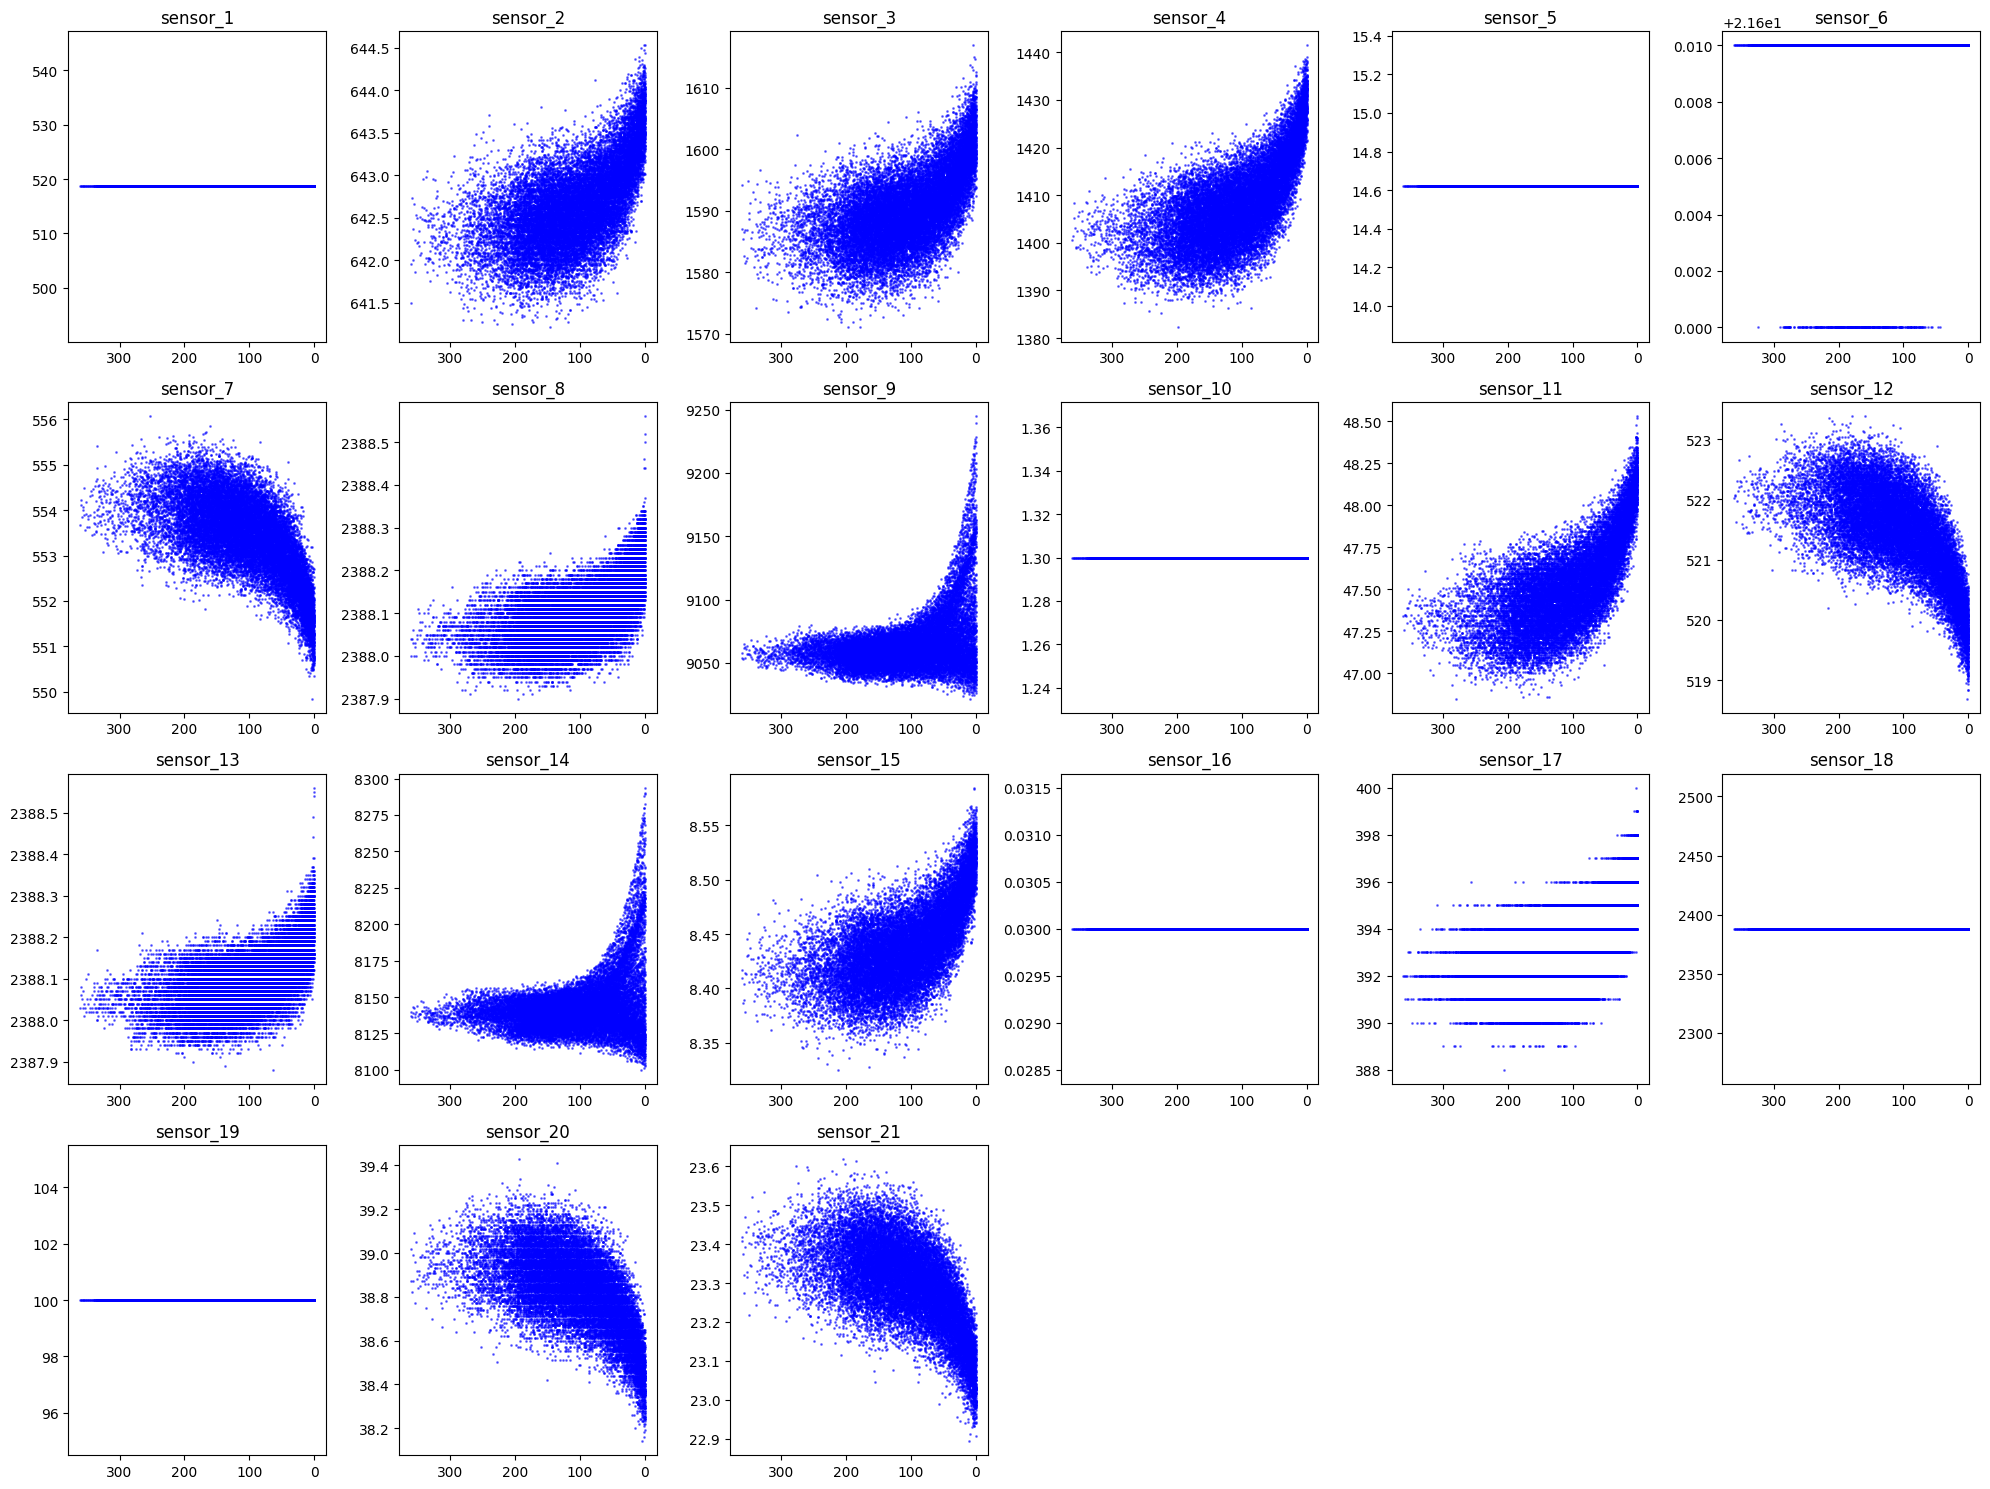

In [7]:
import matplotlib.pyplot as plt

# Grab the sensor columns
sensors = train_df.columns[5:-1]

plt.figure(figsize=(20, 15))

# enumerate(..., 1) gives us 'i' (a number starting at 1) and 'sensor' (the column name)
for i, sensor in enumerate(sensors, 1):
    plt.subplot(4, 6, i) # Creates a grid with 4 rows and 6 columns
    
    # Plot RUL on the X-axis, and the specific sensor on the Y-axis
    plt.scatter(train_df['RUL_current'], train_df[sensor], alpha=0.5, color='blue', s=1)
    
    plt.title(sensor)
    plt.gca().invert_xaxis() # Added the missing parenthesis here!

plt.tight_layout() # This keeps the graphs from squishing together
plt.show() # Actually displays the image)
    

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

In [9]:
from sklearn.ensemble import RandomForestRegressor

# Explicitly separate the features from the target
X_train = train_df.drop(columns=['RUL_current'])
Y_train = train_df['RUL_current']
clf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state = 30)
clf.fit(X_train,Y_train)

RandomForestRegressor(max_depth=5, random_state=30)

In [10]:
importances = clf.feature_importances_

# 2. Get the exact names of the columns the model was trained on
feature_names = X_train.columns

# 3. Create a DataFrame to organize the scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort them so the most important features are at the bottom (for the horizontal plot)
importance_df = importance_df.sort_values(by='Importance', ascending=True)
importance_df

,Feature,Importance
2,op_setting_1,0.000000
4,op_setting_3,0.000000
5,sensor_1,0.000000
9,sensor_5,0.000000
10,sensor_6,0.000000
14,sensor_10,0.000000
22,sensor_18,0.000000
23,sensor_19,0.000000
20,sensor_16,0.000000
21,sensor_17,0.000000


In [11]:
train_df.corr()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL_current
unit_number,1.000000,0.078753,-0.017895,-0.006197,NaN,NaN,0.014133,0.012621,0.026116,NaN,...,0.044230,-0.059473,0.022486,NaN,0.013513,NaN,NaN,-0.020589,-0.016465,0.078753
time_in_cycles,0.078753,1.000000,-0.004527,0.016132,NaN,NaN,0.549898,0.543947,0.624577,NaN,...,0.477523,0.370324,0.588676,NaN,0.566995,NaN,NaN,-0.583597,-0.585923,-0.736241
op_setting_1,-0.017895,-0.004527,1.000000,0.011660,NaN,NaN,0.009030,-0.005651,0.009544,NaN,...,0.002318,-0.004469,0.007652,NaN,0.002599,NaN,NaN,-0.005713,-0.014559,-0.003198
op_setting_2,-0.006197,0.016132,0.011660,1.000000,NaN,NaN,0.007266,0.009068,0.014673,NaN,...,0.018156,-0.006310,0.014156,NaN,0.012280,NaN,NaN,-0.010554,-0.007846,-0.001948
op_setting_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensor_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensor_2,0.014133,0.549898,0.009030,0.007266,NaN,NaN,1.000000,0.602610,0.714949,NaN,...,0.661792,0.179752,0.675975,NaN,0.629886,NaN,NaN,-0.661841,-0.668050,-0.606484
sensor_3,0.012621,0.543947,-0.005651,0.009068,NaN,NaN,0.602610,1.000000,0.678413,NaN,...,0.600963,0.237137,0.639921,NaN,0.600017,NaN,NaN,-0.625941,-0.633901,-0.584520
sensor_4,0.026116,0.624577,0.009544,0.014673,NaN,NaN,0.714949,0.678413,1.000000,NaN,...,0.745158,0.190748,0.758459,NaN,0.703499,NaN,NaN,-0.748067,-0.745193,-0.678948
sensor_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
threshold = 0.0001

# Filter the dataframe to keep only the important features
important_features = importance_df[importance_df['Importance'] >= threshold]['Feature']

# Create your final, hyper-optimized training set!
X_train_final = X_train[important_features]

print(f"Features kept: {len(X_train_final.columns)}")
print(f"Features dropped: {len(X_train.columns) - len(X_train_final.columns)}")
X_train_final = X_train_final.drop(columns = ['unit_number'])
X_test_final = test_df[important_features].drop(columns = ['unit_number'])
X_train_final

Features kept: 12
Features dropped: 14


,sensor_21,sensor_15,sensor_8,sensor_13,sensor_14,sensor_7,sensor_4,sensor_12,sensor_9,sensor_11,time_in_cycles
0,23.4190,8.4195,2388.06,2388.02,8138.62,554.36,1400.60,521.66,9046.19,47.47,1
1,23.4236,8.4318,2388.04,2388.07,8131.49,553.75,1403.14,522.28,9044.07,47.49,2
2,23.3442,8.4178,2388.08,2388.03,8133.23,554.26,1404.20,522.42,9052.94,47.27,3
3,23.3739,8.3682,2388.11,2388.08,8133.83,554.45,1401.87,522.86,9049.48,47.13,4
4,23.4044,8.4294,2388.06,2388.04,8133.80,554.00,1406.22,522.19,9055.15,47.28,5
...,...,...,...,...,...,...,...,...,...,...,...
20626,22.9735,8.4956,2388.19,2388.26,8137.60,551.43,1428.63,519.49,9065.52,48.07,196
20627,23.1594,8.5139,2388.23,2388.22,8136.50,550.86,1433.58,519.68,9065.11,48.04,197
20628,22.9333,8.5646,2388.24,2388.24,8141.05,550.94,1428.18,520.01,9065.90,48.09,198
20629,23.0640,8.5389,2388.25,2388.23,8139.29,550.68,1426.53,519.67,9073.72,48.39,199


In [13]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train_final, Y_train)

LinearRegression()

In [14]:
y_pred = reg.predict(X_test_final)

In [15]:
test_df.tail()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,520.69,2388.00,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,521.05,2388.09,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,521.18,2388.04,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,521.33,2388.08,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699
13095,100,198,0.0013,0.0003,100.0,518.67,642.95,1601.62,1424.99,14.62,...,521.07,2388.05,8214.64,8.4903,0.03,396,2388,100.0,38.70,23.1855


In [16]:
from sklearn.preprocessing import MinMaxScaler

norm_scaler = MinMaxScaler()

# Fit and transform the training data
X_train_normalized = norm_scaler.fit_transform(X_train_final)
# Only transform the test data!
X_test_normalized = norm_scaler.transform(X_test_final)

In [17]:
X_train_new = pd.DataFrame(X_train_normalized, columns=X_train_final.columns)

# Do the exact same thing for your test data array
X_test_new = pd.DataFrame(X_test_normalized, columns=X_test_final.columns)

# Take a look at your beautifully formatted data!
display(X_train_new.head())

,sensor_21,sensor_15,sensor_8,sensor_13,sensor_14,sensor_7,sensor_4,sensor_12,sensor_9,sensor_11,time_in_cycles
0,0.724662,0.363986,0.242424,0.205882,0.199608,0.726248,0.309757,0.633262,0.109755,0.369048,0.00000
1,0.731014,0.411312,0.212121,0.279412,0.162813,0.628019,0.352633,0.765458,0.100242,0.380952,0.00277
2,0.621375,0.357445,0.272727,0.220588,0.171793,0.710145,0.370527,0.795309,0.140043,0.250000,0.00554
3,0.662386,0.166603,0.318182,0.294118,0.174889,0.740741,0.331195,0.889126,0.124518,0.166667,0.00831
4,0.704502,0.402078,0.242424,0.235294,0.174734,0.668277,0.404625,0.746269,0.149960,0.255952,0.01108


In [18]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
Y_train = Y_train.clip(upper=125)
reg.fit(X_train_new, Y_train)

LinearRegression()

In [19]:
test_last_cycle = test_df.groupby('unit_number').last().reset_index()
test_data =  test_last_cycle[important_features].drop(columns = ['unit_number'])

test_norm = norm_scaler.transform(test_data)

In [20]:
y_pred2 = reg.predict(test_norm)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
from sklearn.metrics import r2_score
rul_actual = RUL_df.clip(upper=125)
r2_score(rul_actual, y_pred2)



0.7063483410131353

In [22]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42,learning_rate= 0.1, max_depth=3,subsample=1, colsample_bytree=0.8)
model.fit(X_train_new, Y_train)
y_pred_xg = model.predict(test_norm)

rmse = np.sqrt(mean_squared_error(rul_actual, y_pred_xg))
r2 = r2_score(rul_actual, y_pred_xg)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 16.750
R²: 0.825


In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_new, Y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}
